Importing Necessary Packages

In [1]:
import pandas as pd
import numpy as np
from PIL import Image
from PIL import UnidentifiedImageError
import os

import torch
import torch.nn as nn
from torch.utils.data import random_split
from torch.utils.data import Dataset, DataLoader, Subset
from torch.utils.data.dataloader import default_collate

import torchvision
from torchvision import datasets, transforms
from torchvision.datasets import DatasetFolder
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

# This is for the progress bar
from tqdm.auto import tqdm
# This is for ploting
import matplotlib.pyplot as plt

In [2]:
!git clone https://github.com/EPSRC-NUMBERS/Human-Robot_Finger-Counting_Dataset.git

Cloning into 'Human-Robot_Finger-Counting_Dataset'...
remote: Enumerating objects: 12476, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 12476 (delta 8), reused 5 (delta 1), pack-reused 12454 (from 1)
Receiving objects: 100% (12476/12476), 474.51 MiB | 16.52 MiB/s, done.
Resolving deltas: 100% (2435/2435), done.
Updating files: 100% (28820/28820), done.


In [3]:
!ls /content/Human-Robot_Finger-Counting_Dataset

Backgrounds  Example_Datasets  LICENCE	Raw_Images  README.md  Toolbox


In [4]:
dataset_path = 'Human-Robot_Finger-Counting_Dataset/Example_Datasets/Combined_Fingers_2000_400_400'

In [5]:
dataset = datasets.ImageFolder(root=dataset_path)
len(dataset)

5200

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(degrees=30),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [7]:
train_dir = os.path.join(dataset_path, 'training_set')
test_dir = os.path.join(dataset_path, 'testing_set')
validation_dir = os.path.join(dataset_path, 'validation_set')

In [8]:
class SafeImageFolder(ImageFolder):
    def is_image_valid(self, path):
        """Check if the image at the given path is valid."""
        try:
            with Image.open(path) as img:
                img.verify()  # Verify that the image is valid
            return True
        except (UnidentifiedImageError, OSError):
            return False

    def __init__(self, root, csv_file=None, transform=None, target_transform=None):
        """
        Initialize SafeImageFolder with filtering of corrupted images and optional CSV-based labels.
        The class will only return images and labels (no bounding boxes).
        """
        super(SafeImageFolder, self).__init__(root, transform=transform, target_transform=target_transform)

        if csv_file:
            # Load the CSV file containing filename and class labels (no bounding boxes)
            df = pd.read_csv(csv_file)

            # Create a dictionary from the CSV for faster lookup
            self.trainset_to_label = df.set_index('filename')['class'].to_dict()

            # Filter out corrupted images and map them to class labels from the CSV file
            # Only include samples with valid class labels
            self.samples = [(path, self.get_label_from_filename(os.path.basename(path)))
                            for path, _ in self.samples
                            if self.is_image_valid(path) and self.get_label_from_filename(os.path.basename(path)) is not None]
        else:
            # No CSV file provided, just filter out corrupted images and return original labels
            self.samples = [(path, label) for path, label in self.samples if self.is_image_valid(path)]

    def get_label_from_filename(self, filename):
        """
        Retrieve the class label for a given filename from the CSV-based dictionary.
        Return None if the record does not exist or if the class label is missing.
        """
        return self.trainset_to_label.get(filename, None)

    def __getitem__(self, index):
        path, label = self.samples[index]
        sample = self.loader(path)

        # If the label is None, handle it (e.g., skip or raise an error)
        if label is None:
            raise ValueError(f"Invalid label for image {os.path.basename(path)}")

        if self.transform is not None:
            sample = self.transform(sample)

        if self.target_transform is not None:
            label = self.target_transform(label)

        # Return image and label (no bounding box)
        return sample, label

In [9]:
label_mapping = {
    'one': 0,    # Change from 1 to 0
    'two': 1,
    'three': 2,
    'four': 3,
    'five': 4
}

class ValidationImageFolder(ImageFolder):
    def __init__(self, root, transform=None):
        super().__init__(root, transform=transform)

    def __getitem__(self, index):
        path, _ = self.samples[index]  # Ignore labels here
        sample = self.loader(path)

        if self.transform:
            sample = self.transform(sample)

        # Extract the label from the filename
        filename = os.path.basename(path)
        label_str = filename.split('_')[0]  # Assuming labels are extracted as 'label_img.jpg'
        class_label = label_mapping.get(label_str, -1)  # Use -1 to indicate not found

        # Validate the class label
        if class_label == -1:
            raise ValueError(f"Label '{label_str}' not found in mapping. Filename: {filename}")

        return sample, class_label  # Return the image and its class label

In [10]:
train_dataset = SafeImageFolder(root=train_dir, csv_file='https://raw.githubusercontent.com/EPSRC-NUMBERS/Human-Robot_Finger-Counting_Dataset/refs/heads/master/Example_Datasets/Combined_Fingers_2000_400_400/training_set/silhouettes/all_labels.csv', transform=train_transform)
test_dataset = SafeImageFolder(root=test_dir, csv_file='https://raw.githubusercontent.com/EPSRC-NUMBERS/Human-Robot_Finger-Counting_Dataset/refs/heads/master/Example_Datasets/Combined_Fingers_2000_400_400/testing_set/silhouettes/all_labels.csv', transform=test_transform)
validation_dataset = ValidationImageFolder(root=validation_dir, transform=test_transform)

# Check dataset lengths
print(f"Total number of images in the training set: {len(train_dataset)}")
print(f"Total number of images in the test set: {len(test_dataset)}")
print(f"Total number of images in the validation set: {len(validation_dataset)}")

Total number of images in the training set: 2000
Total number of images in the test set: 400
Total number of images in the validation set: 400


Creating DataLoaders

In [11]:
def custom_collate_fn(batch):
    """
    Collate function for batching images and labels together.
    Expects a batch of (image, label) tuples and returns stacked images and a list of labels.
    This version adjusts labels to be zero-indexed.
    """
    # Unzip the batch into images and labels
    images, labels = zip(*batch)

    # Stack images into a tensor
    images = default_collate(images)  # Use default collate to handle batching of images

    # Adjust labels to be zero-indexed (assuming original labels are 1-based, i.e., 1 to 5)
    labels = [label - 1 for label in labels]  # Subtract 1 to shift to 0-based indexing

    # Convert labels to a tensor (if they're not already)
    labels = torch.tensor(labels, dtype=torch.int64)

    # Return the images and labels
    return images, labels

In [12]:
def validation_collate_fn(batch):
    """
    Collate function for batching images and labels together.
    Expects a batch of (image, label) tuples and returns stacked images and a list of labels.
    """
    # Unzip the batch into images and labels
    images, labels = zip(*batch)

    # Stack images into a tensor
    images = default_collate(images)  # Use default collate to handle batching of images

    # Convert labels to a tensor (if they're not already)
    labels = torch.tensor(labels, dtype=torch.int64)

    # Return the images and labels
    return images, labels

In [13]:
batch_size = 4

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True,collate_fn=custom_collate_fn)
valid_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True, collate_fn=validation_collate_fn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=custom_collate_fn)

In [14]:
for batch_idx, (images, labels) in enumerate(train_loader):  # Assuming train_loader is your DataLoader
    # Print the shape of the images being passed to the model
    print(f"Batch {batch_idx + 1}:")
    print(f"Images shape: {images.shape}")  # Inspect the shape of images tensor
    print(f"Labels: {labels}")  # Print all labels

Batch 1:
Images shape: torch.Size([4, 3, 224, 224])
Labels: tensor([3, 2, 0, 0])
Batch 2:
Images shape: torch.Size([4, 3, 224, 224])
Labels: tensor([0, 4, 1, 4])
Batch 3:
Images shape: torch.Size([4, 3, 224, 224])
Labels: tensor([4, 4, 4, 3])
Batch 4:
Images shape: torch.Size([4, 3, 224, 224])
Labels: tensor([2, 1, 2, 4])
Batch 5:
Images shape: torch.Size([4, 3, 224, 224])
Labels: tensor([3, 3, 0, 2])
Batch 6:
Images shape: torch.Size([4, 3, 224, 224])
Labels: tensor([4, 2, 2, 2])
Batch 7:
Images shape: torch.Size([4, 3, 224, 224])
Labels: tensor([1, 4, 0, 1])
Batch 8:
Images shape: torch.Size([4, 3, 224, 224])
Labels: tensor([3, 2, 0, 1])
Batch 9:
Images shape: torch.Size([4, 3, 224, 224])
Labels: tensor([4, 2, 1, 4])
Batch 10:
Images shape: torch.Size([4, 3, 224, 224])
Labels: tensor([0, 0, 0, 1])
Batch 11:
Images shape: torch.Size([4, 3, 224, 224])
Labels: tensor([4, 3, 4, 4])
Batch 12:
Images shape: torch.Size([4, 3, 224, 224])
Labels: tensor([1, 1, 4, 3])
Batch 13:
Images shape: t

Sample Visualization

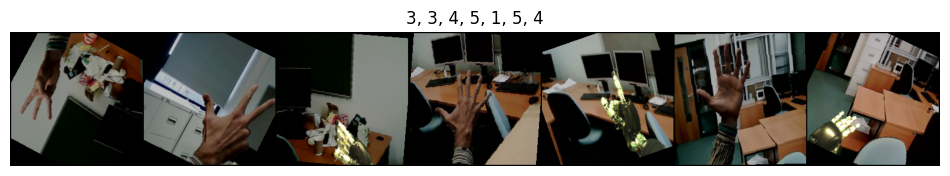

In [15]:
trainset_to_label = {0: '1', 1: '2', 2: '3', 3: '4', 4: '5'}

def imshow(inp, title=None):
    """Display image for Tensor."""

    plt.figure(figsize=(12, 8))
    inp = inp.numpy().transpose((1, 2, 0))  # Convert tensor to numpy and adjust dimensions for plt.imshow
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.axis('off')  # Turn off axis
    plt.pause(0.001)  # Pause to allow display update

# Get batch of images and labels from your DataLoader
train_loader_for_vis = DataLoader(train_dataset, batch_size=7, shuffle=True, num_workers=0, collate_fn=custom_collate_fn)
inputs, labels = next(iter(train_loader_for_vis))  # Assume the second item in batch is labels

# Create a grid of the images
out = torchvision.utils.make_grid(inputs)

# Convert labels to readable titles
titles = [trainset_to_label.get(label.item(), 'Unknown') for label in labels]  # Use integer labels directly

# Visualize the grid of images with the mapped class names as titles
imshow(out, title=', '.join(titles))

Model Building

In [16]:
from torchvision import models
from torchvision.models import resnet50
import time
!pip install torchsummary
from torchsummary import summary

In [17]:
model = models.efficientnet_b7(pretrained=True)

num_classes = 5
in_features = model.classifier[1].in_features  # Get the number of input features to the final layer
model.classifier[1] = nn.Linear(in_features, num_classes)  # Replace the layer

# Transfer the model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Print the modified model (optional)
print(model)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B7_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B7_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b7_lukemelas-c5b4e57e.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b7_lukemelas-c5b4e57e.pth
100%|██████████| 255M/255M [00:16<00:00, 16.6MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
            (1): BatchNorm2d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormAct

In [18]:
summary(model, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           1,728
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              SiLU-3         [-1, 64, 112, 112]               0
            Conv2d-4         [-1, 64, 112, 112]             576
       BatchNorm2d-5         [-1, 64, 112, 112]             128
              SiLU-6         [-1, 64, 112, 112]               0
 AdaptiveAvgPool2d-7             [-1, 64, 1, 1]               0
            Conv2d-8             [-1, 16, 1, 1]           1,040
              SiLU-9             [-1, 16, 1, 1]               0
           Conv2d-10             [-1, 64, 1, 1]           1,088
          Sigmoid-11             [-1, 64, 1, 1]               0
SqueezeExcitation-12         [-1, 64, 112, 112]               0
           Conv2d-13         [-1, 32, 112, 112]           2,048
      BatchNorm2d-14         [-1, 32, 1

Hyperparameters - Loss Function and Optimizer

In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.0003)

Training and Validation Loop

In [20]:
# The number of training epochs.
n_epochs = 50

# These are used to record information
best_valid_acc = 0
train_loss_epochs = []
train_acc_epochs = []
valid_loss_epochs = []
valid_acc_epochs = []

for epoch in range(n_epochs):

    # ---------- Training ----------
    # Make sure the model is in train mode before training.
    model.train()

    # These are used to record information in training.
    train_loss = []
    train_accs = []

    # Iterate the training set by batches.
    for batch in tqdm(train_loader):

        # Gradients stored in the parameters in the previous step should be cleared out first.
        optimizer.zero_grad()

        # A batch consists of image data and corresponding labels.
        imgs, labels = batch
        imgs = imgs.to(device)
        labels = labels.to(device)

        # Forward the data. (Make sure data and model are on the same device.)
        logits = model(imgs)

        # Calculate the cross-entropy loss.
        # We don't need to apply softmax before computing cross-entropy as it is done automatically.
        loss = criterion(logits, labels)

        # Compute the gradients for parameters.
        loss.backward()

        # Update the parameters with computed gradients.
        optimizer.step()

        # Compute the accuracy for current batch.
        acc = (logits.argmax(dim=-1) == labels).float().mean()

        # Record the loss and accuracy.
        train_loss.append(loss.item())
        train_accs.append(acc.item())

    # The average loss and accuracy of the training set is the average of the recorded values.
    train_loss = sum(train_loss) / len(train_loss)
    train_acc = sum(train_accs) / len(train_accs)
    train_loss_epochs.append(train_loss)
    train_acc_epochs.append(train_acc)

    # ---------- Validation ----------
    # Make sure the model is in eval mode so that some modules like dropout are disabled and work normally.
    model.eval()

    # These are used to record information in validation.
    valid_loss = []
    valid_accs = []

    # Iterate the validation set by batches.
    for batch in tqdm(valid_loader):

        # A batch consists of image data and corresponding labels.
        imgs, labels = batch
        imgs = imgs.to(device)
        labels = labels.to(device)

        # We don't need gradient in validation.
        # Using torch.no_grad() accelerates the forward process.
        with torch.no_grad():
          logits = model(imgs)

        # We can still compute the loss (but not the gradient).
        loss = criterion(logits, labels)

        # Compute the accuracy for current batch.
        acc = (logits.argmax(dim=-1) == labels).float().mean()

        # Record the loss and accuracy.
        valid_loss.append(loss.item())
        valid_accs.append(acc.item())

    # The average loss and accuracy for entire validation set is the average of the recorded values.
    valid_loss = sum(valid_loss) / len(valid_loss)
    valid_acc = sum(valid_accs) / len(valid_accs)
    valid_loss_epochs.append(valid_loss)
    valid_acc_epochs.append(valid_acc)

    # save the best model
    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc
        torch.save(model.state_dict(), 'best_model.pth')

    # Print the information.
    print(f"[Epoch: {epoch + 1:03d}/{n_epochs:03d}] Train: loss={train_loss:.5f}, acc={train_acc:.5f} | Valid: loss={valid_loss:.5f}, acc={valid_acc:.5f}")

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

[Epoch: 001/050] Train: loss=1.61136, acc=0.21500 | Valid: loss=1.61367, acc=0.23000


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

[Epoch: 049/050] Train: loss=1.28091, acc=0.46350 | Valid: loss=1.25619, acc=0.50000


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

[Epoch: 050/050] Train: loss=1.27153, acc=0.46700 | Valid: loss=1.23867, acc=0.50000


Plotting Loss Curves

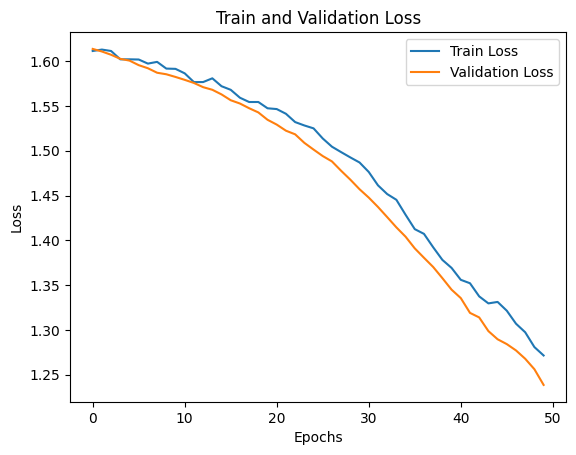

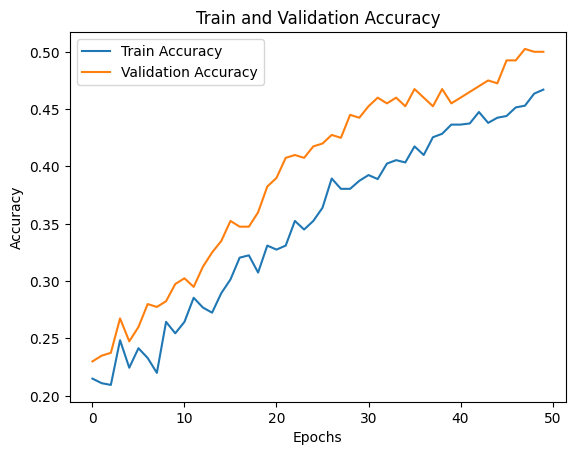

In [21]:
# Plotting the loss curves
plt.figure()
plt.plot(train_loss_epochs, label='Train Loss')
plt.plot(valid_loss_epochs, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train and Validation Loss')
plt.legend()
plt.show()

# Plotting the accuracy curves
plt.figure()
plt.plot(train_acc_epochs, label='Train Accuracy')
plt.plot(valid_acc_epochs, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Train and Validation Accuracy')
plt.legend()
plt.show()

Testing Loop

In [22]:
# load best model weights
model.load_state_dict(torch.load('best_model.pth'))

# Make sure the model is in eval mode.
# Some modules like Dropout or BatchNorm affect if the model is in training mode.
model.eval()

test_accs = []

# Iterate the testing set by batches.
for batch in tqdm(test_loader):
    # A batch consists of image data and corresponding labels.
    imgs, labels = batch
    imgs = imgs.to(device)
    labels = labels.to(device)

    # We don't need gradient in test
    # Using torch.no_grad() accelerates the forward process.
    with torch.no_grad():
      logits = model(imgs)

    # We can still compute the loss (but not the gradient).
    loss = criterion(logits, labels)

    # Compute the accuracy for current batch.
    acc = (logits.argmax(dim=-1) == labels).float().mean()

    # Record accuracy.
    test_accs.append(acc)

# The average accuracy for entire test set is the average of the recorded values.
test_acc = sum(test_accs) / len(test_accs)
print(f'Test accuracy {test_acc}')

<ipython-input-22-7201ed175c95>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth'))


  0%|          | 0/100 [00:00<?, ?it/s]

Test accuracy 0.48499998450279236


Evaluation Metrics and Confusion Matrix

In [23]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [24]:
model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

In [25]:
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')

In [26]:
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")

Accuracy: 0.485
Precision: 0.5284091982020463
Recall: 0.485


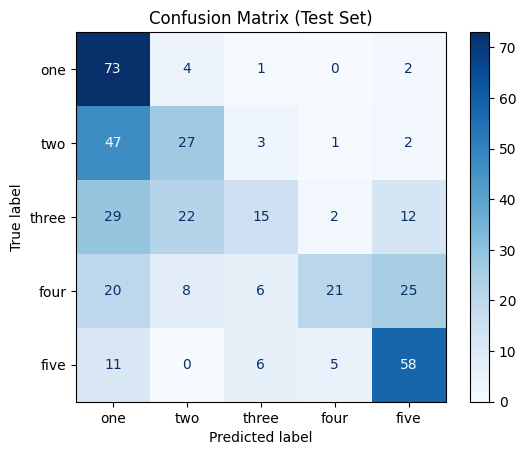

In [27]:
class_names = ['one', 'two', 'three', 'four', 'five']

# Initialize lists to hold all predictions and ground-truth labels
all_preds = []
all_labels = []

# Ensure model is in evaluation mode
model.eval()

# Disable gradient calculation for faster computations
with torch.no_grad():
    for inputs, labels in test_loader:  # Use your test DataLoader here
        inputs = inputs.to(device)  # Move inputs to the correct device (CPU/GPU)
        labels = labels.to(device)  # Move labels to the correct device

        # Forward pass: get predictions
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)  # Get the class with the highest score

        # Collect predictions and labels
        all_preds.append(preds.to(device))  # Keep predictions on the GPU
        all_labels.append(labels.to(device))  # Keep labels on the GPU

# Convert lists to tensors, then move to the correct device
all_preds = torch.cat(all_preds).to(device)  # Concatenate and keep on GPU
all_labels = torch.cat(all_labels).to(device)  # Concatenate and keep on GPU

# Compute confusion matrix (move to CPU for sklearn compatibility)
cm = confusion_matrix(all_labels.cpu().numpy(), all_preds.cpu().numpy())

# Display the confusion matrix using sklearn's ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)

plt.title('Confusion Matrix (Test Set)')
plt.show()

Measuring Time and Memory Usage

In [28]:
def measure_time_and_memory(model, data_loader, criterion, optimizer=None, device='cuda'):
    """
    Measure the average time and memory usage for training or validation/testing.
    If optimizer is provided, it's for training; otherwise, it's for validation/testing.
    """
    model.to(device)
    total_time = 0.0
    total_memory = 0.0
    total_batches = 0

    # Ensure model is in training mode if optimizer is provided
    model.train() if optimizer else model.eval()

    # Disable gradient calculation for validation and testing
    with torch.no_grad() if not optimizer else torch.enable_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            start_time = time.time()  # Start time measurement

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            if optimizer:
                optimizer.zero_grad()
                loss.backward()  # Only needed during training
                optimizer.step()  # Update weights

            end_time = time.time()  # End time measurement

            # Measure memory usage
            memory_usage = torch.cuda.memory_allocated(device) / (1024 * 1024)  # in MB

            total_time += (end_time - start_time)
            total_memory += memory_usage
            total_batches += 1

    average_time = total_time / total_batches if total_batches > 0 else 0
    average_memory = total_memory / total_batches if total_batches > 0 else 0

    return average_time, average_memory


device = 'cuda' if torch.cuda.is_available() else 'cpu'  # Set device to CUDA or CPU based on availability
train_average_time, train_average_memory = measure_time_and_memory(model, train_loader, criterion, optimizer, device)
val_average_time, val_average_memory = measure_time_and_memory(model, valid_loader, criterion, device=device)
test_average_time, test_average_memory = measure_time_and_memory(model, test_loader, criterion, device=device)

print(f"Average Training Time: {train_average_time:.4f} seconds, Average Memory Usage: {train_average_memory:.2f} MB")
print(f"Average Validation Time: {val_average_time:.4f} seconds, Average Memory Usage: {val_average_memory:.2f} MB")
print(f"Average Testing Time: {test_average_time:.4f} seconds, Average Memory Usage: {test_average_memory:.2f} MB")

Average Training Time: 0.1096 seconds, Average Memory Usage: 540.61 MB
Average Validation Time: 0.0325 seconds, Average Memory Usage: 541.21 MB
Average Testing Time: 0.0306 seconds, Average Memory Usage: 541.21 MB
